In [ ]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────────

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── CELL 2 — Install Libraries ───────────────────────────────────────────────
!pip install -q torch torchvision scikit-learn matplotlib seaborn pillow opencv-python-headless grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 96.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ── CELL 3 — Imports ─────────────────────────────────────────────────────────
import os
import shutil
import random
import time
import copy
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# ── CELL 4 — Seed & Device ───────────────────────────────────────────────────
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ── CELL 5 — Project Folder Structure ────────────────────────────────────────
BASE_DIR        = Path('/content/project')
DATA_RAW        = BASE_DIR / 'data' / 'raw'
DATA_CLEAN      = BASE_DIR / 'data' / 'clean'
DATA_FINAL      = BASE_DIR / 'data' / 'final'
TRAIN_DIR       = DATA_FINAL / 'train'
VAL_DIR         = DATA_FINAL / 'val'
TEST_DIR        = DATA_FINAL / 'test'
SAVED_MODELS    = BASE_DIR / 'saved_models'
RESULTS_DIR     = BASE_DIR / 'results'
PLOTS_DIR       = BASE_DIR / 'plots'

CLASSES = ['cow', 'buffalo']

# Create all folders
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASSES:
        (split / cls).mkdir(parents=True, exist_ok=True)

for cls in CLASSES:
    (DATA_RAW   / cls).mkdir(parents=True, exist_ok=True)
    (DATA_CLEAN / cls).mkdir(parents=True, exist_ok=True)

SAVED_MODELS.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Google Drive checkpoint folder
DRIVE_CHECKPOINT = Path('/content/drive/MyDrive/cow_buffalo_project/checkpoints')
DRIVE_CHECKPOINT.mkdir(parents=True, exist_ok=True)

print("Folder structure created successfully!")
print(f"\nProject root: {BASE_DIR}")
print(f"Drive checkpoints: {DRIVE_CHECKPOINT}")

# Verify
for path in [TRAIN_DIR, VAL_DIR, TEST_DIR, SAVED_MODELS, RESULTS_DIR, PLOTS_DIR]:
    print(f"  ✓ {path}")

Folder structure created successfully!

Project root: /content/project
Drive checkpoints: /content/drive/MyDrive/cow_buffalo_project/checkpoints
  ✓ /content/project/data/final/train
  ✓ /content/project/data/final/val
  ✓ /content/project/data/final/test
  ✓ /content/project/saved_models
  ✓ /content/project/results
  ✓ /content/project/plots


In [ ]:
# ── CELL 6 — Global Config ───────────────────────────────────────────────────
CONFIG = {
    'seed'          : 42,
    'img_size'      : 224,
    'batch_size'    : 32,
    'max_epochs'    : 100,
    'patience'      : 10,        # early stopping
    'lr_baseline'   : 1e-3,      # Model 1
    'lr_pretrained' : 1e-4,      # Models 2–5
    'weight_decay'  : 1e-4,
    'lr_factor'     : 0.5,       # ReduceLROnPlateau
    'lr_patience'   : 5,
    'dropout'       : 0.5,
    'dropout_pt'    : 0.4,       # pretrained models
    'num_classes'   : 2,
    'mean'          : [0.485, 0.456, 0.406],
    'std'           : [0.229, 0.224, 0.225],
    'classes'       : ['cow', 'buffalo'],
}

print("Global config set:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Global config set:
  seed: 42
  img_size: 224
  batch_size: 32
  max_epochs: 100
  patience: 10
  lr_baseline: 0.001
  lr_pretrained: 0.0001
  weight_decay: 0.0001
  lr_factor: 0.5
  lr_patience: 5
  dropout: 0.5
  dropout_pt: 0.4
  num_classes: 2
  mean: [0.485, 0.456, 0.406]
  std: [0.229, 0.224, 0.225]
  classes: ['cow', 'buffalo']


In [ ]:
# ── CELL 7 — Upload Dataset ZIP from Local Machine ───────────────────────────
from google.colab import files

print("A file picker will appear below...")
print("Select your zipped dataset folder (e.g. dataset.zip)")

uploaded = files.upload()

# Show what was uploaded
for filename, data in uploaded.items():
    print(f"\nUploaded: {filename}  |  Size: {len(data)/1024/1024:.2f} MB")

A file picker will appear below...
Select your zipped dataset folder (e.g. dataset.zip)


Saving raw.zip to raw.zip

Uploaded: raw.zip  |  Size: 209.04 MB


In [ ]:
# ── CELL 8 — Unzip & Place into Raw Folder ───────────────────────────────────
import zipfile
import os
import shutil
from pathlib import Path

# ── Change this to match your uploaded filename exactly ──────────────────────
ZIP_NAME = list(uploaded.keys())[0]   # auto-picks the uploaded file
EXTRACT_TO = Path('/content/extracted_raw')

# Extract zip
print(f"Extracting: {ZIP_NAME} ...")
with zipfile.ZipFile(ZIP_NAME, 'r') as z:
    z.extractall(EXTRACT_TO)
print("Extraction done!")

# Show what was extracted
print("\nExtracted structure:")
for p in sorted(EXTRACT_TO.rglob('*'))[:20]:
    print(f"  {p}")

Extracting: raw.zip ...
Extraction done!

Extracted structure:
  /content/extracted_raw/raw
  /content/extracted_raw/raw/buffalo
  /content/extracted_raw/raw/buffalo/10_Most_Expensive_Buffalo_Breeds_in_the_.jpg
  /content/extracted_raw/raw/buffalo/1145_Buffalo_Living_Stock_Photos_.jpg
  /content/extracted_raw/raw/buffalo/131_Murrah_Buffalo_for_Dairy_Farming_ (1).jpg
  /content/extracted_raw/raw/buffalo/154_Buffalo_Leather_Stock_Videos.jpg
  /content/extracted_raw/raw/buffalo/1_Hundred_Nili_Ravi_Buffalo_Royalty_ (1).jpg
  /content/extracted_raw/raw/buffalo/1_Hundred_Nili_Ravi_Buffalo_Royalty_.jpg
  /content/extracted_raw/raw/buffalo/1_Hundred_Nili_Ravi_Royalty-Free_ (2).jpg
  /content/extracted_raw/raw/buffalo/1_Hundred_Nili_Ravi_Royalty-Free_.jpg
  /content/extracted_raw/raw/buffalo/28kg_milk_record_Nili_Ravi_Breed.jpg
  /content/extracted_raw/raw/buffalo/2_Buffalo_nille_Ravi_for_sale_muridke_.jpg
  /content/extracted_raw/raw/buffalo/32_-_.jpg
  /content/extracted_raw/raw/buffalo/35_ (

In [ ]:
# ── CELL 9 — Move cow & buffalo to data/raw ───────────────────────────────────
DATA_RAW = Path('/content/project/data/raw')

for cls in ['cow', 'buffalo']:
    # Search for the class folder anywhere inside extracted content
    matches = list(EXTRACT_TO.rglob(cls))
    # Filter to only directories
    matches = [m for m in matches if m.is_dir()]

    if not matches:
        print(f"ERROR: Could not find folder named '{cls}' inside zip!")
        continue

    src = matches[0]
    dst = DATA_RAW / cls

    # Clear destination first to avoid duplicates
    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(src, dst)
    count = len(list(dst.glob('*')))
    print(f"✓ {cls}: {count} files copied → {dst}")

print("\nRaw data ready!")

✓ cow: 900 files copied → /content/project/data/raw/cow
✓ buffalo: 874 files copied → /content/project/data/raw/buffalo

Raw data ready!


In [ ]:
# ── CELL 10 — Verify Raw Dataset Counts ──────────────────────────────────────
DATA_RAW = Path('/content/project/data/raw')

print("=" * 45)
print("RAW DATASET SUMMARY")
print("=" * 45)

total = 0
for cls in ['cow', 'buffalo']:
    cls_path = DATA_RAW / cls
    # Count all common image extensions
    images = [f for f in cls_path.glob('*')
              if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
    print(f"  {cls.upper():10s}: {len(images):>5} images")
    total += len(images)

print("-" * 45)
print(f"  {'TOTAL':10s}: {total:>5} images")
print("=" * 45)
print("\nExpected → cow: ~900  |  buffalo: ~874")

RAW DATASET SUMMARY
  COW       :   900 images
  BUFFALO   :   874 images
---------------------------------------------
  TOTAL     :  1774 images

Expected → cow: ~900  |  buffalo: ~874


In [ ]:
# ── CELL 11 — Dataset Cleaning ───────────────────────────────────────────────
import hashlib
from PIL import Image, ImageStat
import shutil
from pathlib import Path

DATA_RAW   = Path('/content/project/data/raw')
DATA_CLEAN = Path('/content/project/data/clean')

MIN_SIZE  = 50          # minimum width AND height in pixels
MAX_BLANK = 10.0        # std-dev threshold — below this = blank/solid image

stats = {}

for cls in ['cow', 'buffalo']:
    src_dir = DATA_RAW   / cls
    dst_dir = DATA_CLEAN / cls

    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    all_files = [f for f in src_dir.glob('*')
                 if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.webp']]

    kept = 0
    removed_corrupt  = 0
    removed_small    = 0
    removed_blank    = 0
    removed_dup      = 0
    seen_hashes      = set()

    for fpath in all_files:
        # 1 — Corrupt check
        try:
            img = Image.open(fpath)
            img.verify()                    # catches truncated files
            img = Image.open(fpath)         # reopen after verify
            img = img.convert('RGB')        # normalize mode
        except Exception:
            removed_corrupt += 1
            continue

        # 2 — Size check
        w, h = img.size
        if w < MIN_SIZE or h < MIN_SIZE:
            removed_small += 1
            continue

        # 3 — Blank / solid image check
        stat = ImageStat.Stat(img)
        mean_std = sum(stat.stddev) / 3.0
        if mean_std < MAX_BLANK:
            removed_blank += 1
            continue

        # 4 — Duplicate check (md5 hash of raw bytes)
        file_hash = hashlib.md5(fpath.read_bytes()).hexdigest()
        if file_hash in seen_hashes:
            removed_dup += 1
            continue
        seen_hashes.add(file_hash)

        # ── Passed all checks → save as JPEG to clean/
        save_path = dst_dir / (fpath.stem + '.jpg')
        img.save(save_path, 'JPEG', quality=95)
        kept += 1

    stats[cls] = {
        'original' : len(all_files),
        'kept'     : kept,
        'corrupt'  : removed_corrupt,
        'small'    : removed_small,
        'blank'    : removed_blank,
        'duplicate': removed_dup,
    }

# ── Report
print("=" * 55)
print("CLEANING REPORT")
print("=" * 55)
for cls, s in stats.items():
    print(f"\n  {cls.upper()}")
    print(f"    Original  : {s['original']}")
    print(f"    Corrupt   : {s['corrupt']}")
    print(f"    Too small : {s['small']}")
    print(f"    Blank     : {s['blank']}")
    print(f"    Duplicate : {s['duplicate']}")
    print(f"    ✓ Kept    : {s['kept']}")
print("=" * 55)
total_clean = sum(s['kept'] for s in stats.values())
print(f"\n  TOTAL CLEAN IMAGES: {total_clean}")

CLEANING REPORT

  COW
    Original  : 900
    Corrupt   : 0
    Too small : 0
    Blank     : 0
    Duplicate : 0
    ✓ Kept    : 900

  BUFFALO
    Original  : 874
    Corrupt   : 0
    Too small : 0
    Blank     : 0
    Duplicate : 61
    ✓ Kept    : 813

  TOTAL CLEAN IMAGES: 1713


In [ ]:
# ── CELL 12 — Verify Clean Dataset ───────────────────────────────────────────
DATA_CLEAN = Path('/content/project/data/clean')

print("=" * 45)
print("CLEAN DATASET SUMMARY")
print("=" * 45)

counts = {}
for cls in ['cow', 'buffalo']:
    images = list((DATA_CLEAN / cls).glob('*.jpg'))
    counts[cls] = len(images)
    print(f"  {cls.upper():10s}: {counts['cow'] if cls=='cow' else counts['buffalo']:>5} images")

total = sum(counts.values())
print("-" * 45)
print(f"  {'TOTAL':10s}: {total:>5} images")
print("=" * 45)

# Class balance ratio
ratio = min(counts.values()) / max(counts.values())
print(f"\n  Balance ratio : {ratio:.3f}  (1.0 = perfect balance)")
print(f"  Imbalance     : {'Mild — WeightedRandomSampler will handle it' if ratio > 0.85 else 'Moderate — check carefully'}")
print("\n✓ Ready for splitting!")

CLEAN DATASET SUMMARY
  COW       :   900 images
  BUFFALO   :   813 images
---------------------------------------------
  TOTAL     :  1713 images

  Balance ratio : 0.903  (1.0 = perfect balance)
  Imbalance     : Mild — WeightedRandomSampler will handle it

✓ Ready for splitting!


In [ ]:
# ── CELL 13 — Stratified Split 70 / 15 / 15 ─────────────────────────────────
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

DATA_CLEAN = Path('/content/project/data/clean')
TRAIN_DIR  = Path('/content/project/data/final/train')
VAL_DIR    = Path('/content/project/data/final/val')
TEST_DIR   = Path('/content/project/data/final/test')

SEED = 42

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if split.exists():
        shutil.rmtree(split)
    for cls in ['cow', 'buffalo']:
        (split / cls).mkdir(parents=True, exist_ok=True)

split_stats = {}

for cls in ['cow', 'buffalo']:
    all_images = sorted((DATA_CLEAN / cls).glob('*.jpg'))
    all_images = [str(p) for p in all_images]

    train_val, test = train_test_split(
        all_images, test_size=0.15, random_state=SEED, shuffle=True
    )
    train, val = train_test_split(
        train_val, test_size=0.176, random_state=SEED, shuffle=True
    )

    for fpath in train:
        shutil.copy(fpath, TRAIN_DIR / cls / Path(fpath).name)
    for fpath in val:
        shutil.copy(fpath, VAL_DIR   / cls / Path(fpath).name)
    for fpath in test:
        shutil.copy(fpath, TEST_DIR  / cls / Path(fpath).name)

    split_stats[cls] = {
        'train': len(train), 'val': len(val),
        'test' : len(test),  'total': len(all_images)
    }

print("=" * 55)
print("SPLIT SUMMARY (70 / 15 / 15)")
print("=" * 55)
print(f"  {'CLASS':10s} {'TOTAL':>7} {'TRAIN':>7} {'VAL':>7} {'TEST':>7}")
print("-" * 55)
for cls, s in split_stats.items():
    print(f"  {cls.upper():10s} {s['total']:>7} {s['train']:>7} {s['val']:>7} {s['test']:>7}")
print("-" * 55)
totals = {k: sum(s[k] for s in split_stats.values()) for k in ['total','train','val','test']}
print(f"  {'TOTAL':10s} {totals['total']:>7} {totals['train']:>7} {totals['val']:>7} {totals['test']:>7}")
print("=" * 55)
print(f"\n✓ Train: {totals['train']}  |  Val: {totals['val']}  |  Test: {totals['test']}")
print("✓ TEST SET IS NOW FROZEN — never touch it during training")

SPLIT SUMMARY (70 / 15 / 15)
  CLASS        TOTAL   TRAIN     VAL    TEST
-------------------------------------------------------
  COW            900     630     135     135
  BUFFALO        813     569     122     122
-------------------------------------------------------
  TOTAL         1713    1199     257     257

✓ Train: 1199  |  Val: 257  |  Test: 257
✓ TEST SET IS NOW FROZEN — never touch it during training


In [ ]:
# ── CELL 14 — Backup Split to Google Drive ───────────────────────────────────
import shutil
from pathlib import Path

SRC = Path('/content/project/data/final')
DST = Path('/content/drive/MyDrive/cow_buffalo_project/data_final')

if DST.exists():
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)
print(f"✓ Split backed up to Google Drive → {DST}")
print("  Restore anytime with: shutil.copytree(DST, SRC)")

✓ Split backed up to Google Drive → /content/drive/MyDrive/cow_buffalo_project/data_final
  Restore anytime with: shutil.copytree(DST, SRC)


In [ ]:
# ── CELL 15 — Transforms & DataLoaders ───────────────────────────────────────
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from pathlib import Path
import torch
import numpy as np

TRAIN_DIR = Path('/content/project/data/final/train')
VAL_DIR   = Path('/content/project/data/final/val')
TEST_DIR  = Path('/content/project/data/final/test')

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Datasets
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = ImageFolder(TEST_DIR,  transform=val_test_transforms)

# ── WeightedRandomSampler for class imbalance
class_counts   = np.array([len(list((TRAIN_DIR / cls).glob('*.jpg')))
                            for cls in train_dataset.classes])
class_weights  = 1.0 / class_counts
sample_weights = np.array([class_weights[label]
                            for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

# ── DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False,  num_workers=2, pin_memory=True)

# ── Summary
print("=" * 45)
print("DATALOADER SUMMARY")
print("=" * 45)
print(f"  Classes       : {train_dataset.classes}")
print(f"  Class → index : {train_dataset.class_to_idx}")
print(f"  Train samples : {len(train_dataset)}")
print(f"  Val   samples : {len(val_dataset)}")
print(f"  Test  samples : {len(test_dataset)}")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Class counts  : cow={class_counts[train_dataset.class_to_idx['cow']]}, "
      f"buffalo={class_counts[train_dataset.class_to_idx['buffalo']]}")
print(f"  Class weights : {dict(zip(train_dataset.classes, class_weights.round(5)))}")
print("=" * 45)
print("✓ WeightedRandomSampler active — imbalance handled")

DATALOADER SUMMARY
  Classes       : ['buffalo', 'cow']
  Class → index : {'buffalo': 0, 'cow': 1}
  Train samples : 1199
  Val   samples : 257
  Test  samples : 257
  Train batches : 38
  Val   batches : 9
  Class counts  : cow=630, buffalo=569
  Class weights : {'buffalo': np.float64(0.00176), 'cow': np.float64(0.00159)}
✓ WeightedRandomSampler active — imbalance handled


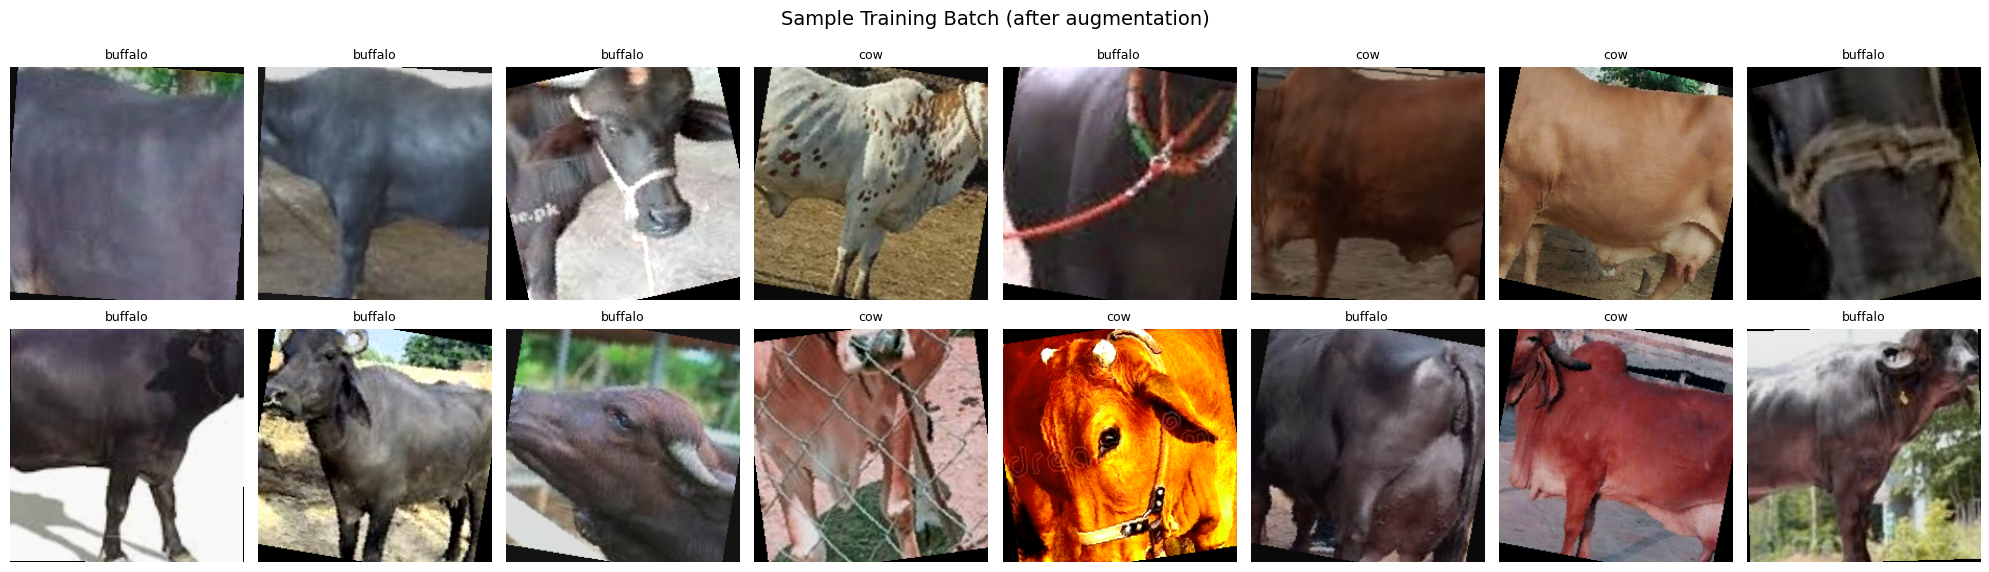

✓ Sample batch plot saved to plots/sample_batch.png


In [ ]:
# ── CELL 16 — Visualize Sample Batch (FIXED) ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import os  # ✅ added

def denormalize(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    t = tensor.clone()
    for i in range(3):
        t[i] = t[i] * std[i] + mean[i]
    return t.clamp(0, 1)

images, labels = next(iter(train_loader))
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Sample Training Batch (after augmentation)', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= len(images): break
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()], fontsize=9)
    ax.axis('off')

plt.tight_layout()

# ✅ FIX: create directory before saving
os.makedirs('/content/project/plots', exist_ok=True)

plt.savefig('/content/project/plots/sample_batch.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Sample batch plot saved to plots/sample_batch.png")

In [ ]:
# ── CELL 17 — Baseline CNN Model ─────────────────────────────────────
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Global Average Pooling
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
model = BaselineCNN()

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.5, inplace=False)
    (3

In [ ]:
# ── CELL 18 — Training Setup (FIXED) ─────────────────────────
import torch.optim as optim

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Using device: {device}")

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Scheduler (FIXED: removed verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

Using device: cuda


In [ ]:
# ── CELL 19 — Sanity Check (Forward Pass) ─────────────────────────
model.eval()

images, labels = next(iter(train_loader))

# Move to device
images = images.to(device)
labels = labels.to(device)

# Forward pass
with torch.no_grad():
    outputs = model(images)

print(f"Input shape  : {images.shape}")
print(f"Output shape : {outputs.shape}")

Input shape  : torch.Size([32, 3, 224, 224])
Output shape : torch.Size([32, 2])


In [ ]:
# ── CELL 20 — Training Loop (UPDATED FOR FIGURE 1) ─────────────────────
from tqdm import tqdm
import os

EPOCHS = 100   # 🔥 change from 100 → 10 (for curves)
best_val_loss = float('inf')
patience = 10
counter = 0

# ✅ ADD THESE (IMPORTANT)
train_losses_model1 = []
val_losses_model1 = []

# Create save directory
os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # ── TRAINING ──
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION ──
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADD THIS (STORE LOSSES)
    train_losses_model1.append(train_loss)
    val_losses_model1.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Scheduler step
    scheduler.step(val_loss)

    # ── SAVE BEST MODEL ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model1_baseline.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    # ── EARLY STOPPING ──
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

# ✅ CHECK
print("\nStored Loss Values:", len(train_losses_model1), len(val_losses_model1))


Epoch [1/100]


100%|██████████| 38/38 [00:13<00:00,  2.80it/s]


Train Loss: 0.4715 | Val Loss: 0.4380
✓ Best model saved

Epoch [2/100]


100%|██████████| 38/38 [00:12<00:00,  3.09it/s]


Train Loss: 0.4481 | Val Loss: 0.4687

Epoch [3/100]


...

Train Loss: 0.3083 | Val Loss: 0.4998

Epoch [10/100]


100%|██████████| 38/38 [00:11<00:00,  3.30it/s]


Train Loss: 0.3641 | Val Loss: 0.4974

Epoch [11/100]


100%|██████████| 38/38 [00:15<00:00,  2.49it/s]


Train Loss: 0.3491 | Val Loss: 0.4965
⛔ Early stopping triggered

Stored Loss Values: 11 11


In [ ]:
import shutil

shutil.copy(
    '/content/project/saved_models/model1_baseline.pth',
    '/content/drive/MyDrive/model1_baseline.pth'
)

print("✓ Model saved to Google Drive")

✓ Model saved to Google Drive


In [ ]:
# ── CELL 21 — Evaluation Metrics ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # probability of class 1

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 1 — TEST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

NameError: name 'model' is not defined

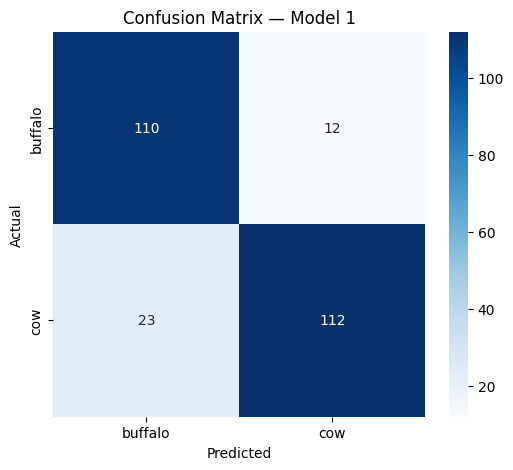

In [ ]:
# ── CELL 22 — Confusion Matrix ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 1')

plt.savefig('/content/project/plots/confusion_matrix_model1.png')
plt.show()

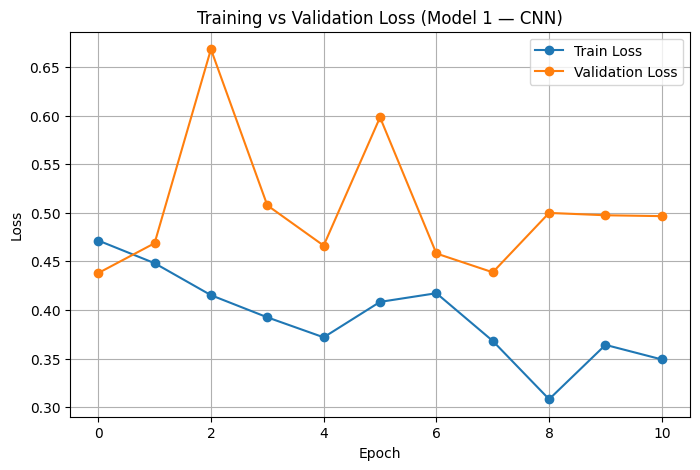

✓ Graph saved as figure1_model1.png


In [ ]:
# ── PLOT FIGURE 1 (MODEL 1) ─────────────────────────
import matplotlib.pyplot as plt
import os

# Create folder if not exists
os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(train_losses_model1, marker='o', label='Train Loss')
plt.plot(val_losses_model1, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 1 — CNN)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model1.png', dpi=150)
plt.show()

print("✓ Graph saved as figure1_model1.png")

In [ ]:
# ── CELL 23 — MobileNetV2 Model ─────────────────────────────────────
import torch.nn as nn
from torchvision import models

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights='DEFAULT')

# Freeze all backbone layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

# Move to device
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 59.0MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# ── CELL 24 — Optimizer Setup (MobileNetV2) ─────────────────────
import torch.optim as optim

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer (ONLY classifier parameters will update)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("✓ Optimizer and scheduler ready")

✓ Optimizer and scheduler ready


In [ ]:
train_losses_model2 = []
val_losses_model2 = []

In [ ]:
# ── CELL 25 — Training (Frozen Backbone) ─────────────────────
from tqdm import tqdm
import os

EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"\n[Phase 1] Epoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model2.append(train_loss)
    val_losses_model2.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)


[Phase 1] Epoch 1/10


100%|██████████| 38/38 [00:15<00:00,  2.41it/s]


Train Loss: 0.4497 | Val Loss: 0.4192

[Phase 1] Epoch 2/10


100%|██████████| 38/38 [00:13<00:00,  2.81it/s]


Train Loss: 0.3537 | Val Loss: 0.3183

[Phase 1] Epoch 3/10


...

Train Loss: 0.2543 | Val Loss: 0.2337

[Phase 1] Epoch 9/10


100%|██████████| 38/38 [00:12<00:00,  3.09it/s]


Train Loss: 0.2667 | Val Loss: 0.2530

[Phase 1] Epoch 10/10


100%|██████████| 38/38 [00:11<00:00,  3.20it/s]


Train Loss: 0.2507 | Val Loss: 0.2097


In [ ]:
# ── CELL 26 — Unfreeze Top Layers ─────────────────────

# Unfreeze last few layers
for param in model.features[-4:].parameters():
    param.requires_grad = True

print("✓ Top layers unfrozen for fine-tuning")

✓ Top layers unfrozen for fine-tuning


In [ ]:
# ── CELL 27 — Fine-Tuning ─────────────────────
EPOCHS = 50
patience = 10
counter = 0
best_val_loss = float('inf')

os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\n[Phase 2] Epoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model2.append(train_loss)
    val_losses_model2.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    # SAVE BEST
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model2_mobilenet.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


[Phase 2] Epoch 1/50


100%|██████████| 38/38 [00:11<00:00,  3.17it/s]


Train Loss: 0.2214 | Val Loss: 0.1800
✓ Best model saved

[Phase 2] Epoch 2/50


100%|██████████| 38/38 [00:12<00:00,  3.11it/s]


Train Loss: 0.1621 | Val Loss: 0.1201
✓ Best model saved

[Phase 2] Epoch 3/50


...

Train Loss: 0.0460 | Val Loss: 0.0432

[Phase 2] Epoch 22/50


100%|██████████| 38/38 [00:11<00:00,  3.45it/s]


Train Loss: 0.0316 | Val Loss: 0.0613

[Phase 2] Epoch 23/50


100%|██████████| 38/38 [00:10<00:00,  3.68it/s]


Train Loss: 0.0366 | Val Loss: 0.0479
⛔ Early stopping triggered


In [ ]:
import shutil

shutil.copy(
    '/content/project/saved_models/model2_mobilenet.pth',
    '/content/drive/MyDrive/model2_mobilenet.pth'
)

print("✓ Model 2 saved to Google Drive")

✓ Model 2 saved to Google Drive


In [ ]:
# ── CELL 28 — Load Saved Model 2 ─────────────────────────
model.load_state_dict(torch.load('/content/project/saved_models/model2_mobilenet.pth'))
model.eval()

print("✓ Model 2 loaded successfully")

✓ Model 2 loaded successfully


In [ ]:
# ── CELL 29 — Evaluation Metrics ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Convert
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 2 — TEST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

MODEL 2 — TEST RESULTS
Accuracy  : 0.9922
Precision : 0.9926
Recall    : 0.9926
F1 Score  : 0.9926
AUC-ROC   : 0.9999


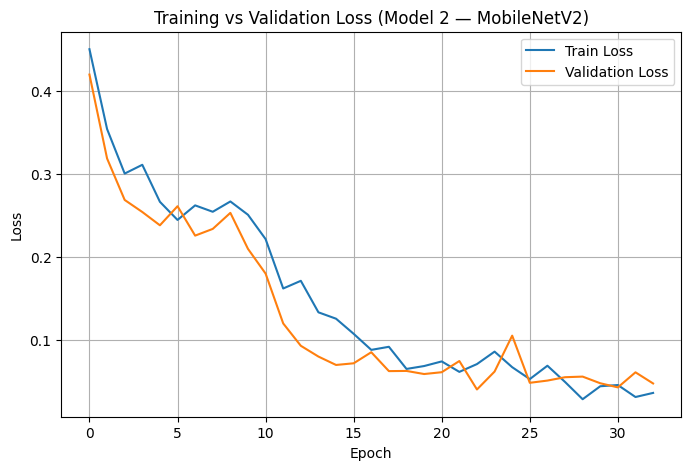

✓ Model 2 graph saved


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses_model2, label='Train Loss')
plt.plot(val_losses_model2, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 2 — MobileNetV2)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model2.png', dpi=150)
plt.show()

print("✓ Model 2 graph saved")

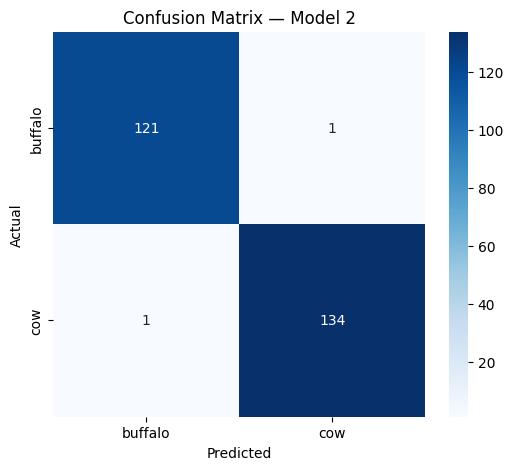

In [ ]:
# ── CELL 30 — Confusion Matrix ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 2')

plt.savefig('/content/project/plots/confusion_matrix_model2.png')
plt.show()

In [ ]:
# ── CELL 31 — ResNet50 Model ─────────────────────────
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet50
model = models.resnet50(weights='DEFAULT')

# Freeze early layers (keep deeper layers trainable later)
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

# Move to device
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# ── CELL 32 — Optimizer ─────────────────────────
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("✓ Optimizer ready")

✓ Optimizer ready


In [ ]:
train_losses_model3 = []
val_losses_model3 = []

In [ ]:
# ── CELL 33 — Phase 1 Training ─────────────────────────
from tqdm import tqdm

EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\n[Phase 1] Epoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model3.append(train_loss)
    val_losses_model3.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)


[Phase 1] Epoch 1/10


100%|██████████| 38/38 [00:17<00:00,  2.16it/s]


Train Loss: 0.6256 | Val Loss: 0.5474

[Phase 1] Epoch 2/10


100%|██████████| 38/38 [00:16<00:00,  2.25it/s]


Train Loss: 0.4628 | Val Loss: 0.4042

[Phase 1] Epoch 3/10


...

Train Loss: 0.2244 | Val Loss: 0.1830

[Phase 1] Epoch 9/10


100%|██████████| 38/38 [00:12<00:00,  2.97it/s]


Train Loss: 0.2469 | Val Loss: 0.1904

[Phase 1] Epoch 10/10


100%|██████████| 38/38 [00:13<00:00,  2.73it/s]


Train Loss: 0.2012 | Val Loss: 0.1750


In [ ]:
# ── CELL 34 — Unfreeze Last Layers ─────────────────────────

# Unfreeze last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True

print("✓ Layer4 unfrozen for fine-tuning")

✓ Layer4 unfrozen for fine-tuning


In [ ]:
# ── CELL 35 — Fine-Tuning ─────────────────────────
import os

EPOCHS = 50
patience = 10
counter = 0
best_val_loss = float('inf')

os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\n[Phase 2] Epoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model3.append(train_loss)
    val_losses_model3.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model3_resnet.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


[Phase 2] Epoch 1/50


100%|██████████| 38/38 [00:13<00:00,  2.77it/s]


Train Loss: 0.1874 | Val Loss: 0.0786
✓ Best model saved

[Phase 2] Epoch 2/50


100%|██████████| 38/38 [00:13<00:00,  2.74it/s]


Train Loss: 0.1039 | Val Loss: 0.0612
✓ Best model saved

[Phase 2] Epoch 3/50


...

Train Loss: 0.0100 | Val Loss: 0.0276

[Phase 2] Epoch 25/50


100%|██████████| 38/38 [00:11<00:00,  3.18it/s]


Train Loss: 0.0195 | Val Loss: 0.0295

[Phase 2] Epoch 26/50


100%|██████████| 38/38 [00:12<00:00,  3.05it/s]


Train Loss: 0.0153 | Val Loss: 0.0312
⛔ Early stopping triggered


In [ ]:
import shutil

shutil.copy(
    '/content/project/saved_models/model3_resnet.pth',
    '/content/drive/MyDrive/model3_resnet.pth'
)

print("✓ Model 3 saved to Google Drive")

✓ Model 3 saved to Google Drive


In [ ]:
# ── CELL 36 — Load ResNet50 Model ─────────────────────────
model.load_state_dict(torch.load('/content/project/saved_models/model3_resnet.pth'))
model.eval()

print("✓ Model 3 loaded successfully")

✓ Model 3 loaded successfully


In [ ]:
# ── CELL 37 — Evaluation Metrics ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 3 — TEST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

MODEL 3 — TEST RESULTS
Accuracy  : 0.9883
Precision : 0.9853
Recall    : 0.9926
F1 Score  : 0.9889
AUC-ROC   : 0.9999


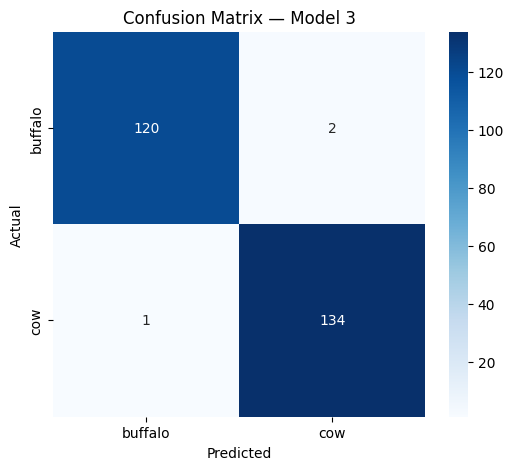

In [ ]:
# ── CELL 38 — Confusion Matrix ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 3')

plt.savefig('/content/project/plots/confusion_matrix_model3.png')
plt.show()

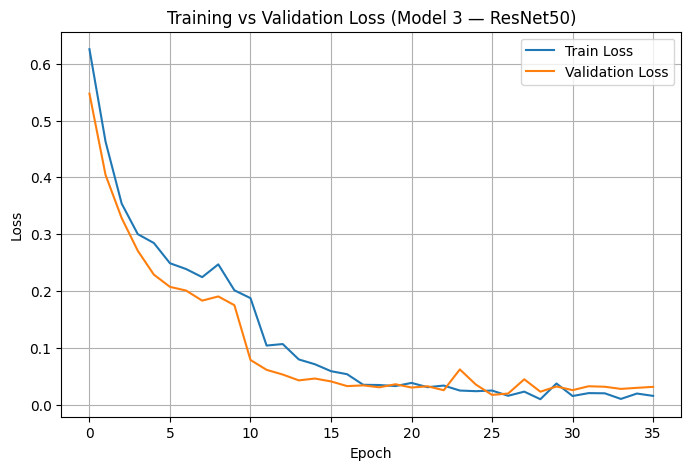

✓ Model 3 graph saved


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses_model3, label='Train Loss')
plt.plot(val_losses_model3, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 3 — ResNet50)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model3.png', dpi=150)
plt.show()

print("✓ Model 3 graph saved")

In [ ]:
# ── CELL 39 — Install OpenCV ─────────────────────────
!pip install opencv-python

import cv2
import numpy as np

In [ ]:
# ── CELL 40 — Custom Dataset with Morphological Features (FIXED) ─────────────
from torch.utils.data import Dataset
from torchvision.datasets import ImageFolder
from PIL import Image
import torch
import cv2
import numpy as np

class HybridDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = ImageFolder(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def extract_features(self, img_path):
        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Threshold
        _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return np.zeros(3, dtype=np.float32)

        cnt = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / (h + 1e-5)

        area = cv2.contourArea(cnt)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull) + 1e-5
        solidity = area / hull_area

        rect_area = w * h + 1e-5
        extent = area / rect_area

        return np.array([aspect_ratio, solidity, extent], dtype=np.float32)

    def __getitem__(self, idx):
        path, label = self.dataset.samples[idx]

        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        morph_features = self.extract_features(path)

        # ✅ FIX: force float32 dtype
        morph_features = torch.tensor(morph_features, dtype=torch.float32)

        return image, morph_features, label

In [ ]:
# ── CELL 41 — Hybrid DataLoaders ─────────────────────────
from torch.utils.data import DataLoader

train_dataset = HybridDataset(TRAIN_DIR, transform=train_transforms)
val_dataset   = HybridDataset(VAL_DIR,   transform=val_test_transforms)
test_dataset  = HybridDataset(TEST_DIR,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("✓ Hybrid DataLoaders ready")

✓ Hybrid DataLoaders ready


In [ ]:
# ── CELL 42 — Hybrid Model ─────────────────────────
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()

        self.cnn = models.resnet50(weights='DEFAULT')

        # Remove final layer
        self.cnn.fc = nn.Identity()

        # Morphological branch
        self.morph_fc = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU()
        )

        # Fusion
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, image, morph):
        cnn_features = self.cnn(image)
        morph_features = self.morph_fc(morph)

        combined = torch.cat((cnn_features, morph_features), dim=1)
        output = self.classifier(combined)

        return output

model = HybridModel().to(device)
print(model)

HybridModel(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [ ]:
# ── CELL 43 — Sanity Check (Hybrid Model) ─────────────────────────
model.eval()

images, morphs, labels = next(iter(train_loader))

images = images.to(device)
morphs = morphs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images, morphs)

print(f"Image shape   : {images.shape}")
print(f"Morph shape   : {morphs.shape}")
print(f"Output shape  : {outputs.shape}")

Image shape   : torch.Size([32, 3, 224, 224])
Morph shape   : torch.Size([32, 3])
Output shape  : torch.Size([32, 2])


In [ ]:
# ── CELL 44 — Optimizer ─────────────────────────
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("✓ Hybrid optimizer ready")

✓ Hybrid optimizer ready


In [ ]:
train_losses_model4 = []
val_losses_model4 = []

In [ ]:
# ── CELL 45 — Hybrid Training ─────────────────────────
from tqdm import tqdm
import os

EPOCHS = 50
patience = 10
counter = 0
best_val_loss = float('inf')

os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\n[Hybrid] Epoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()
    train_loss = 0

    for images, morphs, labels in tqdm(train_loader):
        images = images.to(device)
        morphs = morphs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, morphs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, morphs, labels in val_loader:
            images = images.to(device)
            morphs = morphs.to(device)
            labels = labels.to(device)

            outputs = model(images, morphs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model4.append(train_loss)
    val_losses_model4.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    # SAVE BEST
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model4_morphology.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    # EARLY STOPPING
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


[Hybrid] Epoch 1/50


100%|██████████| 38/38 [00:23<00:00,  1.59it/s]


Train Loss: 0.4044 | Val Loss: 0.2230
✓ Best model saved

[Hybrid] Epoch 2/50


100%|██████████| 38/38 [00:19<00:00,  1.94it/s]


Train Loss: 0.1640 | Val Loss: 0.0815
✓ Best model saved

[Hybrid] Epoch 3/50


...

Train Loss: 0.0145 | Val Loss: 0.0415

[Hybrid] Epoch 20/50


100%|██████████| 38/38 [00:19<00:00,  1.99it/s]


Train Loss: 0.0139 | Val Loss: 0.0466

[Hybrid] Epoch 21/50


100%|██████████| 38/38 [00:20<00:00,  1.85it/s]


Train Loss: 0.0114 | Val Loss: 0.0411
⛔ Early stopping triggered


In [ ]:
# ── CELL 46 — Load Hybrid Model ─────────────────────────
model.load_state_dict(torch.load('/content/project/saved_models/model4_morphology.pth'))
model.eval()

print("✓ Model 4 loaded successfully")

✓ Model 4 loaded successfully


In [ ]:
# ── CELL 47 — Evaluation Metrics (Hybrid) ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, morphs, labels in test_loader:
        images = images.to(device)
        morphs = morphs.to(device)
        labels = labels.to(device)

        outputs = model(images, morphs)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 4 — TEST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

MODEL 4 — TEST RESULTS
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
AUC-ROC   : 1.0000


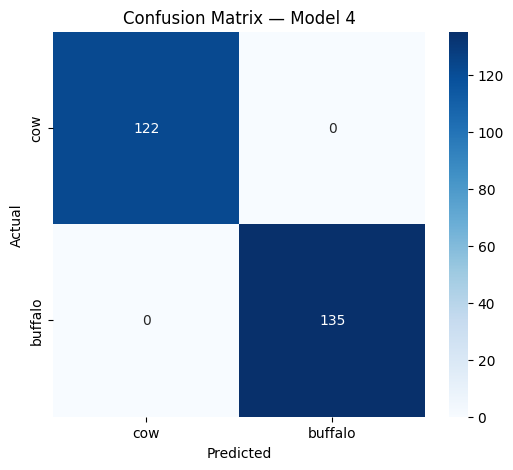

In [ ]:
# ── CELL 48 — Confusion Matrix ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)
class_names = ['cow', 'buffalo']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 4')

plt.savefig('/content/project/plots/confusion_matrix_model4.png')
plt.show()

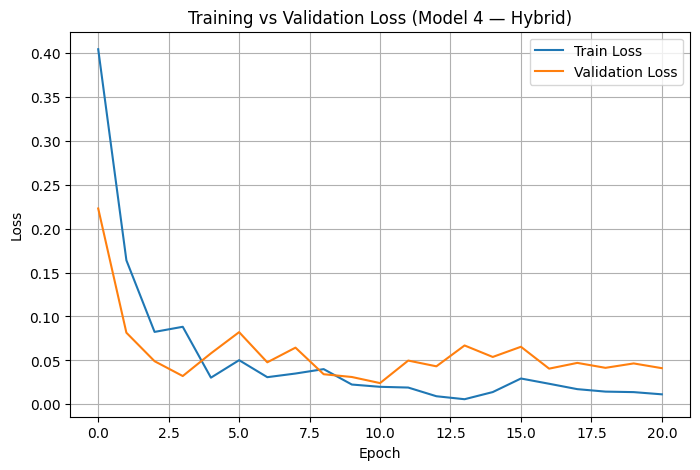

✓ Model 4 graph saved


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses_model4, label='Train Loss')
plt.plot(val_losses_model4, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 4 — Hybrid)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model4.png', dpi=150)
plt.show()

print("✓ Model 4 graph saved")

In [ ]:
# ── CELL 41 (UPDATED FOR MODEL 5) — Standard DataLoaders ───────────────────
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Datasets (ONLY image + label)
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = ImageFolder(TEST_DIR,  transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("✓ Standard DataLoaders ready for Model 5")

✓ Standard DataLoaders ready for Model 5


In [ ]:
# ── CELL 49 — CBAM Module ─────────────────────────
import torch
import torch.nn as nn

# Channel Attention
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()

        avg = self.fc(self.avg_pool(x).view(b, c))
        max_ = self.fc(self.max_pool(x).view(b, c))

        out = avg + max_
        return x * self.sigmoid(out).view(b, c, 1, 1)


# Spatial Attention
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg, max_], dim=1)
        return x * self.sigmoid(self.conv(x_cat))


# CBAM block
class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

In [ ]:
# ── CELL 50 — ResNet50 + CBAM ─────────────────────────
from torchvision import models

class ResNet50_CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet50(weights='DEFAULT')

        self.features = nn.Sequential(
            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3,
            base.layer4,
        )

        self.cbam = CBAM(2048)

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)   # 🔥 Attention applied here
        x = self.pool(x)
        x = self.classifier(x)
        return x


model = ResNet50_CBAM().to(device)
print("✓ CBAM model ready")

✓ CBAM model ready


In [ ]:
# ── CELL 51 — Optimizer ─────────────────────────
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [ ]:
train_losses_model5 = []
val_losses_model5 = []

In [ ]:
# ── CELL 52 — Training CBAM ─────────────────────────
from tqdm import tqdm
import os

EPOCHS = 50
patience = 10
counter = 0
best_val_loss = float('inf')

os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\n[CBAM] Epoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (LOSS TRACKING)
    train_losses_model5.append(train_loss)
    val_losses_model5.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model5_cbam.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


[CBAM] Epoch 1/50


100%|██████████| 38/38 [00:24<00:00,  1.55it/s]


Train Loss: 0.5893 | Val Loss: 0.2425
✓ Best model saved

[CBAM] Epoch 2/50


100%|██████████| 38/38 [00:21<00:00,  1.78it/s]


Train Loss: 0.2020 | Val Loss: 0.1221
✓ Best model saved

[CBAM] Epoch 3/50


...

Train Loss: 0.0139 | Val Loss: 0.0539

[CBAM] Epoch 14/50


100%|██████████| 38/38 [00:16<00:00,  2.27it/s]


Train Loss: 0.0087 | Val Loss: 0.0723

[CBAM] Epoch 15/50


100%|██████████| 38/38 [00:16<00:00,  2.24it/s]


Train Loss: 0.0144 | Val Loss: 0.0701
⛔ Early stopping triggered


In [ ]:
import shutil

shutil.copy(
    '/content/project/saved_models/model5_cbam.pth',
    '/content/drive/MyDrive/model5_cbam.pth'
)

print("✓ CBAM model saved to Google Drive")

✓ CBAM model saved to Google Drive


In [ ]:
# ── CELL 53 — Load CBAM Model ─────────────────────────
model.load_state_dict(torch.load('/content/project/saved_models/model5_cbam.pth'))
model.eval()

print("✓ CBAM model loaded")

✓ CBAM model loaded


In [ ]:
# ── CELL 54 — Evaluation Metrics (CBAM) ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 5 — CBAM RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

MODEL 5 — CBAM RESULTS
Accuracy  : 0.9883
Precision : 0.9925
Recall    : 0.9852
F1 Score  : 0.9888
AUC-ROC   : 0.9980


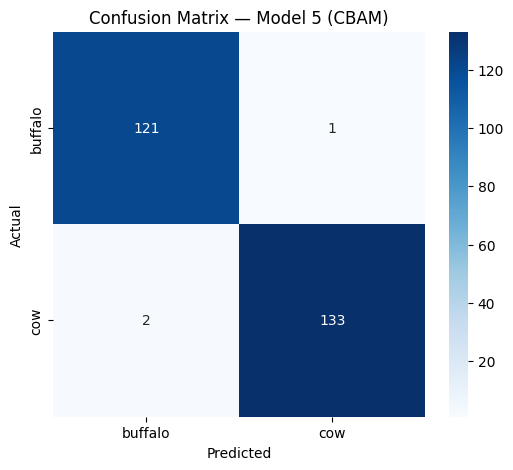

✓ Model 5 confusion matrix saved


In [ ]:
# ── CONFUSION MATRIX — MODEL 5 (CBAM) ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

os.makedirs('/content/project/plots', exist_ok=True)

# -------- LOAD MODEL --------
model.load_state_dict(torch.load('/content/project/saved_models/model5_cbam.pth'))
model.eval()

# -------- GET PREDICTIONS --------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(all_labels, all_preds)

# ⚠️ IMPORTANT: correct class order
class_names = ['buffalo', 'cow']

# -------- PLOT --------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 5 (CBAM)')

plt.savefig('/content/project/plots/confusion_matrix_model5.png', dpi=150)
plt.show()

print("✓ Model 5 confusion matrix saved")

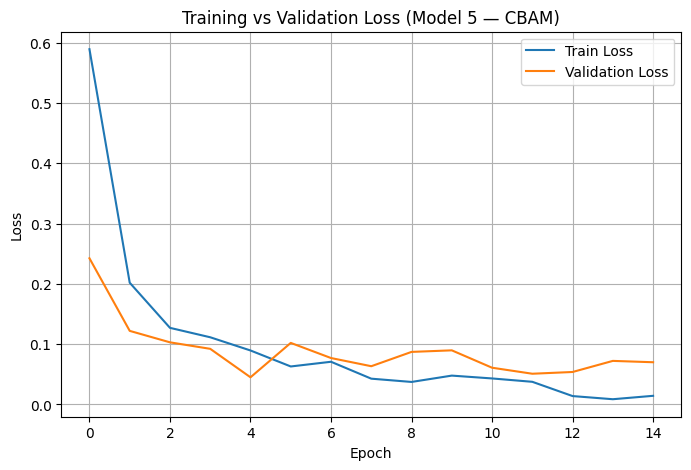

✓ Model 5 graph saved


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses_model5, label='Train Loss')
plt.plot(val_losses_model5, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 5 — CBAM)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model5.png', dpi=150)
plt.show()

print("✓ Model 5 graph saved")

In [ ]:
# ── CELL 55 — ResNet50 (No CBAM FIXED) ─────────────────────────
from torchvision import models
import torch.nn as nn
import torch.optim as optim

model = models.resnet50(weights='DEFAULT')

# Replace classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

# ✅ IMPORTANT: NEW optimizer (DON'T reuse old one)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("✓ No-CBAM model + optimizer ready")

✓ No-CBAM model + optimizer ready


In [ ]:
train_losses_model5_nocbam = []
val_losses_model5_nocbam = []

In [ ]:
# ── CELL 56 — Training No-CBAM (FIXED) ─────────────────────────
from tqdm import tqdm
import os

EPOCHS = 50
patience = 10
counter = 0
best_val_loss = float('inf')

# ✅ ADDED (LOSS LISTS)
train_losses_model5_nocbam = []
val_losses_model5_nocbam = []

os.makedirs('/content/project/saved_models', exist_ok=True)

for epoch in range(EPOCHS):
    print(f"\n[No-CBAM] Epoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ✅ ADDED (STORE LOSSES)
    train_losses_model5_nocbam.append(train_loss)
    val_losses_model5_nocbam.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/project/saved_models/model5_no_cbam.pth')
        print("✓ Best model saved")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


[No-CBAM] Epoch 1/50


100%|██████████| 38/38 [00:20<00:00,  1.86it/s]


Train Loss: 0.4599 | Val Loss: 0.3638
✓ Best model saved

[No-CBAM] Epoch 2/50


100%|██████████| 38/38 [00:18<00:00,  2.10it/s]


Train Loss: 0.1493 | Val Loss: 0.2137
✓ Best model saved

[No-CBAM] Epoch 3/50


...

Train Loss: 0.0061 | Val Loss: 0.0189

[No-CBAM] Epoch 26/50


100%|██████████| 38/38 [00:16<00:00,  2.32it/s]


Train Loss: 0.0046 | Val Loss: 0.0192

[No-CBAM] Epoch 27/50


100%|██████████| 38/38 [00:16<00:00,  2.34it/s]


Train Loss: 0.0040 | Val Loss: 0.0208
⛔ Early stopping triggered


In [ ]:
import shutil

shutil.copy(
    '/content/project/saved_models/model5_no_cbam.pth',
    '/content/drive/MyDrive/model5_no_cbam.pth'
)

print("✓ No-CBAM model saved to Google Drive")

✓ No-CBAM model saved to Google Drive


In [ ]:
# ── CELL 57 — Load No-CBAM Model ─────────────────────────
model.load_state_dict(torch.load('/content/project/saved_models/model5_no_cbam.pth'))
model.eval()

print("✓ No-CBAM model loaded")

✓ No-CBAM model loaded


In [ ]:
# ── CELL 58 — Evaluation Metrics (No-CBAM) ─────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print("="*40)
print("MODEL 5 — NO CBAM RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print("="*40)

MODEL 5 — NO CBAM RESULTS
Accuracy  : 0.9883
Precision : 0.9925
Recall    : 0.9852
F1 Score  : 0.9888
AUC-ROC   : 0.9998


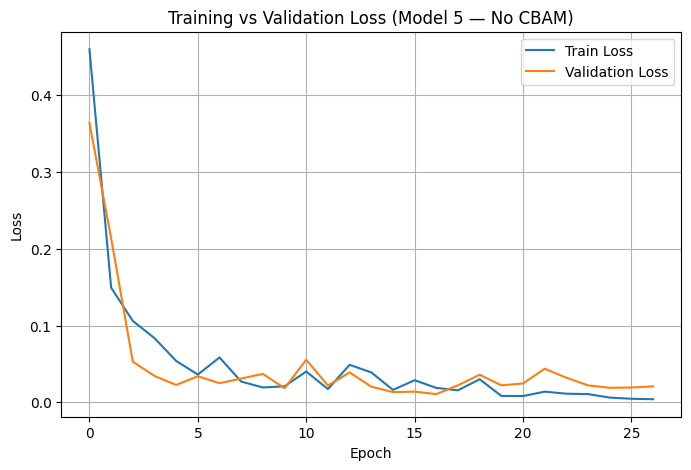

✓ No-CBAM graph saved


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses_model5_nocbam, label='Train Loss')
plt.plot(val_losses_model5_nocbam, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Model 5 — No CBAM)')
plt.legend()
plt.grid()

plt.savefig('/content/project/plots/figure1_model5_nocbam.png', dpi=150)
plt.show()

print("✓ No-CBAM graph saved")

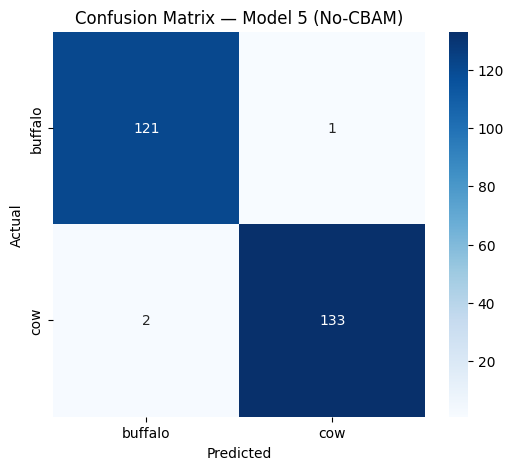

✓ No-CBAM confusion matrix saved


In [ ]:
# ── CONFUSION MATRIX — MODEL 5 (NO-CBAM) ─────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

os.makedirs('/content/project/plots', exist_ok=True)

# -------- LOAD MODEL --------
model.load_state_dict(torch.load('/content/project/saved_models/model5_no_cbam.pth'))
model.eval()

# -------- GET PREDICTIONS --------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(all_labels, all_preds)

# ⚠️ correct class mapping
class_names = ['buffalo', 'cow']

# -------- PLOT --------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 5 (No-CBAM)')

plt.savefig('/content/project/plots/confusion_matrix_model5_nocbam.png', dpi=150)
plt.show()

print("✓ No-CBAM confusion matrix saved")

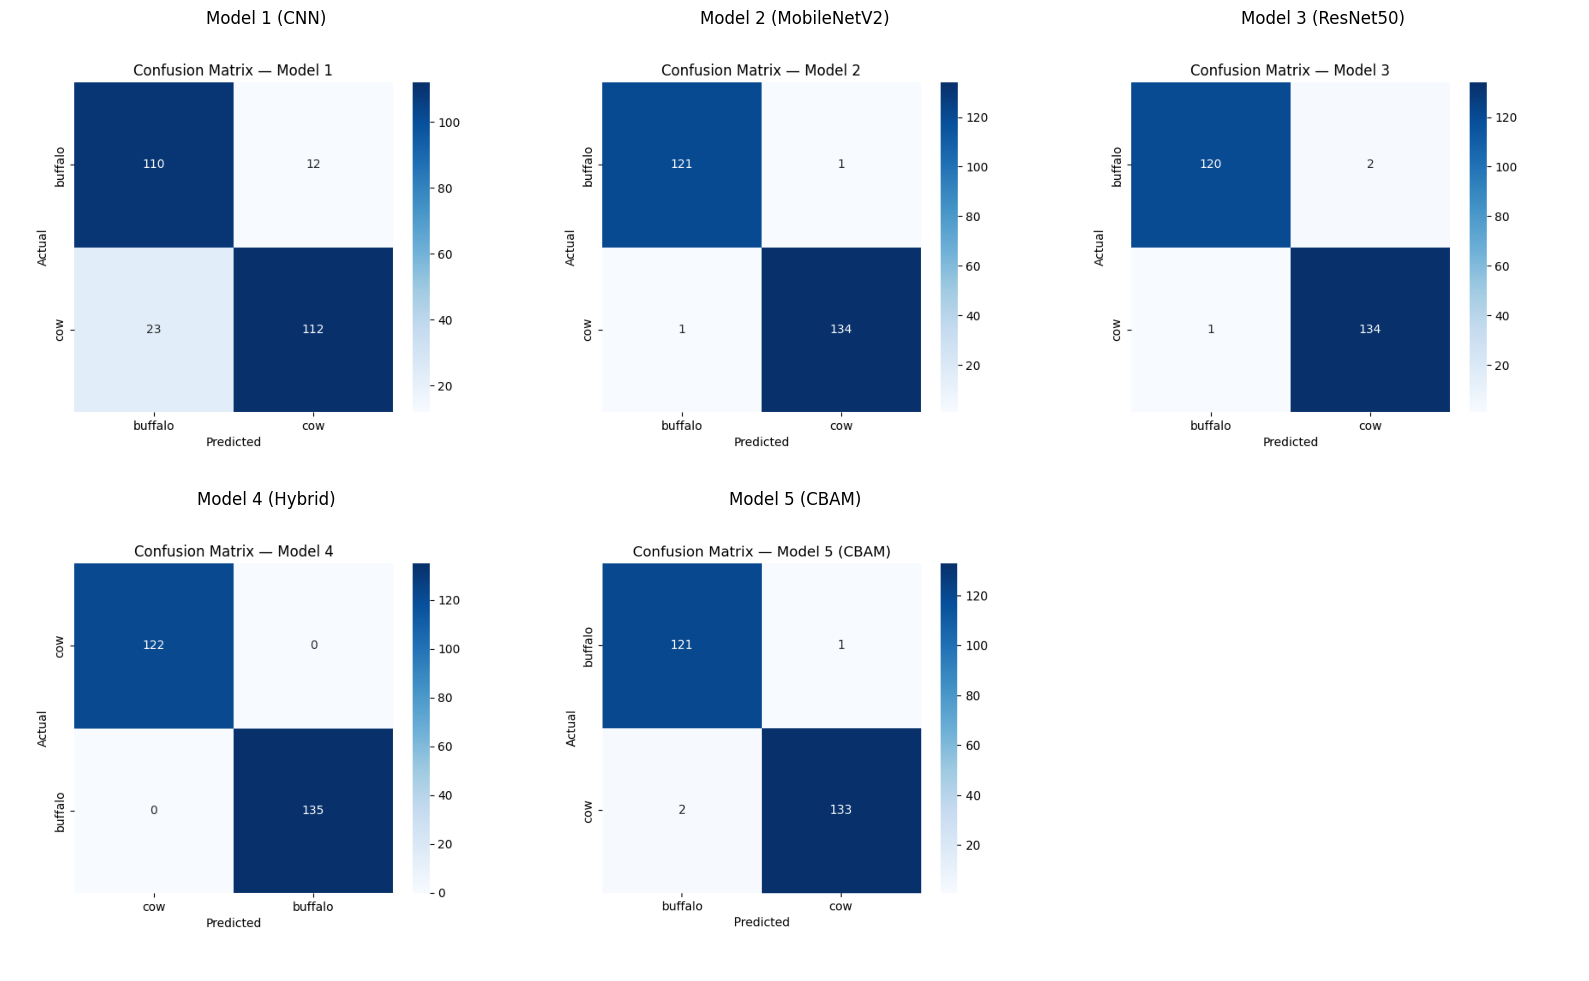

✓ Combined confusion matrix figure saved


In [ ]:
# ── COMBINE SAVED CONFUSION MATRIX IMAGES ─────────────────────────

import matplotlib.pyplot as plt
import cv2
import os

# Image paths
paths = [
    '/content/project/plots/confusion_matrix_model1.png',
    '/content/project/plots/confusion_matrix_model2.png',
    '/content/project/plots/confusion_matrix_model3.png',
    '/content/project/plots/confusion_matrix_model4.png',
    '/content/project/plots/confusion_matrix_model5.png'
]

titles = [
    "Model 1 (CNN)",
    "Model 2 (MobileNetV2)",
    "Model 3 (ResNet50)",
    "Model 4 (Hybrid)",
    "Model 5 (CBAM)"
]

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(16,10))

for ax, path, title in zip(axes.flat, paths, titles):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

# Remove empty subplot
axes[1,2].axis('off')

plt.tight_layout()

# Save final figure
plt.savefig('/content/project/plots/figure2_all_confusion.png', dpi=150)

plt.show()

print("✓ Combined confusion matrix figure saved")

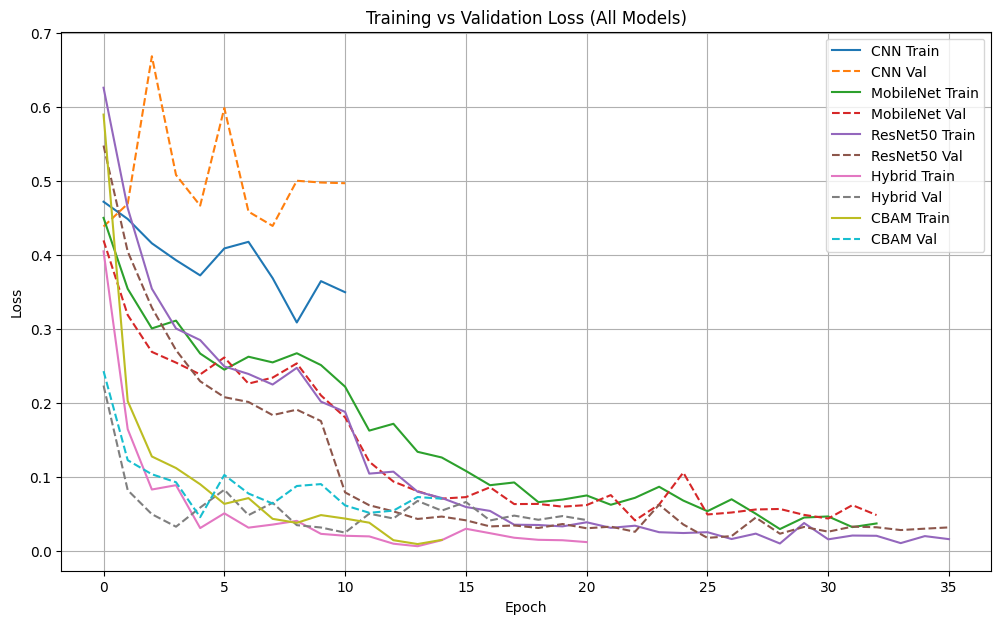

✓ Figure 1 (all models) saved


In [ ]:
# ── FIGURE 1 — ALL MODELS (TRAIN vs VALIDATION LOSS) ─────────────────────────

import matplotlib.pyplot as plt
import os

os.makedirs('/content/project/plots', exist_ok=True)

plt.figure(figsize=(12,7))

# -------- MODEL 1 --------
plt.plot(train_losses_model1, linestyle='-', label='CNN Train')
plt.plot(val_losses_model1, linestyle='--', label='CNN Val')

# -------- MODEL 2 --------
plt.plot(train_losses_model2, linestyle='-', label='MobileNet Train')
plt.plot(val_losses_model2, linestyle='--', label='MobileNet Val')

# -------- MODEL 3 --------
plt.plot(train_losses_model3, linestyle='-', label='ResNet50 Train')
plt.plot(val_losses_model3, linestyle='--', label='ResNet50 Val')

# -------- MODEL 4 --------
plt.plot(train_losses_model4, linestyle='-', label='Hybrid Train')
plt.plot(val_losses_model4, linestyle='--', label='Hybrid Val')

# -------- MODEL 5 --------
plt.plot(train_losses_model5, linestyle='-', label='CBAM Train')
plt.plot(val_losses_model5, linestyle='--', label='CBAM Val')

# -------- SETTINGS --------
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (All Models)')
plt.legend()
plt.grid()

# Save
plt.savefig('/content/project/plots/figure1_all_models.png', dpi=150)

# Show
plt.show()

print("✓ Figure 1 (all models) saved")

In [ ]:
import torch
import cv2
import numpy as np

def generate_gradcam(model, image_tensor, target_layer):
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    target_layer.register_forward_hook(forward_hook)
    target_layer.register_backward_hook(backward_hook)

    output = model(image_tensor)
    pred = output.argmax()

    model.zero_grad()
    output[0, pred].backward()

    grad = gradients[0]
    act = activations[0]

    weights = grad.mean(dim=(2,3), keepdim=True)
    cam = (weights * act).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam = cam / cam.max()

    return cam

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from PIL import Image

image_path = '/content/extracted_raw/test2.jpg'

image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

In [ ]:
from torchvision import models
import torch.nn as nn

# Load ResNet50
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

model.load_state_dict(torch.load('/content/project/saved_models/model3_resnet.pth'))
model = model.to(device)
model.eval()

# Target layer
target_layer = model.layer4[-1]

cam_resnet = generate_gradcam(model, input_tensor, target_layer)

In [ ]:
# IMPORTANT: Your CBAM class must already be defined

cbam_model = ResNet50_CBAM().to(device)

cbam_model.load_state_dict(torch.load('/content/project/saved_models/model5_cbam.pth'))
cbam_model.eval()

# Best layer for Grad-CAM
target_layer_cbam = cbam_model.features[-1]

# Generate CAM
cam_cbam = generate_gradcam(cbam_model, input_tensor, target_layer_cbam)

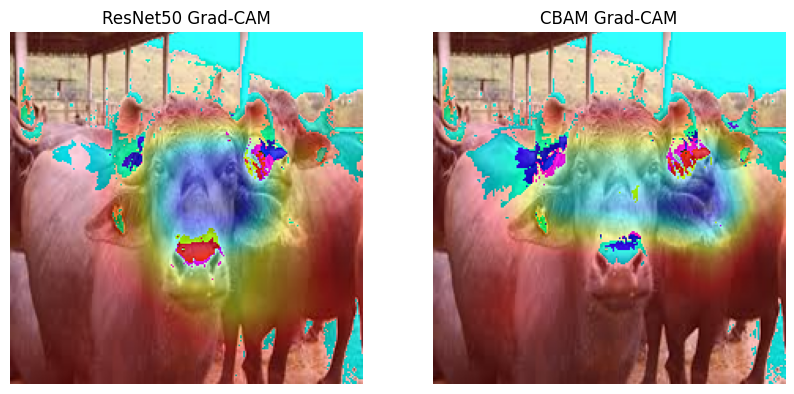

✓ Figure 3 saved successfully


In [ ]:
os.makedirs('/content/project/plots', exist_ok=True)

img = np.array(image.resize((224,224)))

# ResNet overlay
heatmap1 = cv2.applyColorMap(np.uint8(255*cam_resnet), cv2.COLORMAP_JET)
overlay1 = heatmap1 * 0.4 + img

# CBAM overlay
heatmap2 = cv2.applyColorMap(np.uint8(255*cam_cbam), cv2.COLORMAP_JET)
overlay2 = heatmap2 * 0.4 + img

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(overlay1.astype(np.uint8))
plt.title("ResNet50 Grad-CAM")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(overlay2.astype(np.uint8))
plt.title("CBAM Grad-CAM")
plt.axis('off')

plt.savefig('/content/project/plots/figure3_gradcam.png', dpi=150)
plt.show()

print("✓ Figure 3 saved successfully")

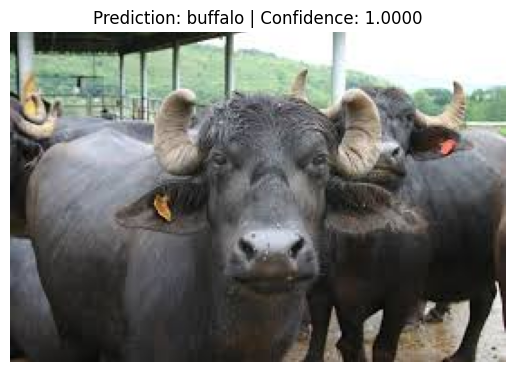

In [ ]:
# ── TEST REAL IMAGE ─────────────────────────
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load model (ResNet50 best)
from torchvision import models
import torch.nn as nn

model = models.resnet50(weights=None)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

model.load_state_dict(torch.load('/content/project/saved_models/model3_resnet.pth'))
model = model.to(device)
model.eval()

# Class names
class_names = ['buffalo', 'cow']

# Transforms
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ✅ YOUR IMAGE PATH
image_path = '/content/extracted_raw/test2.jpg'

# Load image
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

# Show result
plt.imshow(image)
plt.title(f"Prediction: {class_names[pred]} | Confidence: {probs[0][pred]:.4f}")
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = '/content/drive/MyDrive/'

files = os.listdir(drive_path)
print(files)

['Colab Notebooks', 'Getting started.pdf', 'Development Notes English.pdf', 'POWER SHARING NOTES ENGLISH.pdf', 'Motka caste certificate.pdf', 'Motka income certificate.pdf', 'Motka residence certificate.pdf', 'Caste Certificate (1).pdf', 'Income certificate.pdf', 'GDFlix Pro', 'BRCCO_2022_4650309 (1).pdf', '881036157754244.pdf', 'BOBCCO_2022_66475 (1).pdf', 'New Certificate (2).pdf', 'New Certificate (1).pdf', 'New Certificate.pdf', 'quadratic_equation_eng_1606297330.pdf', 'BRCCO_2022_4650309.pdf', '1644402964034History-of-Indian-Art-term-2-final-copy.pdf', 'Class Notes.pdf', 'HTML Codes (1).pdf', 'HTML Codes.pdf', 'Document from Ankit Kumar.pdf', 'REPORTTTT-compressed.pdf', 'Etp Practicles.zip', 'CertificateOfCompletion_Become a FullStack Web Developer.pdf', 'Leadership Through Social influence.pdf', "ANKIT'S Dream CV .pdf.pdf", 'GANTTCHART ANKITpdf.jpg', 'BCCCO_2021_6001902 (1).pdf', 'BOBCCO_2022_66475.pdf', 'BCCCO_2021_6001902.pdf', 'BICCO_2021_5454026.pdf', '0d22deb9bc2e46578f3c798

In [ ]:
plots_path = '/content/project/plots'

print(os.listdir(plots_path))

['confusion_matrix_model1.png', 'figure1_model3.png', 'sample_batch.png', 'figure1_model1.png', 'confusion_matrix_model5.png', 'figure3_gradcam.png', 'confusion_matrix_model4.png', 'confusion_matrix_model5_nocbam.png', 'figure2_all_confusion.png', 'confusion_matrix_model3.png', 'figure1_model4.png', 'figure1_all_models.png', 'figure1_model5.png', 'figure1_model2.png', 'confusion_matrix_model2.png', 'figure1_model5_nocbam.png']


In [ ]:
shutil.copy('/content/project/plots/figure1_all_models.png', '/content/drive/MyDrive/')
shutil.copy('/content/project/plots/figure2_all_confusion.png', '/content/drive/MyDrive/')
shutil.copy('/content/project/plots/figure3_gradcam.png', '/content/drive/MyDrive/')

print("✓ All figures saved to Drive")

✓ All figures saved to Drive


In [ ]:
import shutil
import os

# Make folder in Drive
os.makedirs('/content/drive/MyDrive/project_plots', exist_ok=True)

# Copy all plots
shutil.copytree('/content/project/plots', '/content/drive/MyDrive/project_plots', dirs_exist_ok=True)

print("✓ All figures copied to Google Drive")

✓ All figures copied to Google Drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/project_plots'))

['confusion_matrix_model1.png', 'figure1_model3.png', 'sample_batch.png', 'figure1_model1.png', 'confusion_matrix_model5.png', 'figure3_gradcam.png', 'confusion_matrix_model4.png', 'confusion_matrix_model5_nocbam.png', 'figure2_all_confusion.png', 'confusion_matrix_model3.png', 'figure1_model4.png', 'figure1_all_models.png', 'figure1_model5.png', 'figure1_model2.png', 'confusion_matrix_model2.png', 'figure1_model5_nocbam.png']


In [ ]:
shutil.copytree('/content/project/plots', '/content/drive/MyDrive/project_plots', dirs_exist_ok=True)

'/content/drive/MyDrive/project_plots'

In [ ]:
import shutil
import os

# Create folder in Drive
os.makedirs('/content/drive/MyDrive/project_models', exist_ok=True)

# Copy all models
shutil.copytree(
    '/content/project/saved_models',
    '/content/drive/MyDrive/project_models',
    dirs_exist_ok=True
)

print("✓ All models saved to Google Drive")

✓ All models saved to Google Drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/project_models'))

['model2_mobilenet.pth', 'model5_no_cbam.pth', 'model5_cbam.pth', 'model1_baseline.pth', 'model3_resnet.pth', 'model4_morphology.pth']
